In [1]:
import time
import os
import random
import numpy as np                                                
import matplotlib.pyplot as plt                                   
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp      
import scipy, scipy.ndimage, scipy.sparse, scipy.sparse.linalg    
                                                     
# import gym
import gymnasium as gym
# from gym import spaces
from gymnasium import spaces


from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
from scipy.signal import convolve2d
import torch as th
from scipy.ndimage import gaussian_filter
from numba import jit, njit
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv

In [2]:
%load_ext Cython

In [3]:
%%cython
import numpy as np
cimport numpy as np
from libc.math cimport sqrt, fabs

In [4]:
x0, y0 = 20, 20

In [5]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=-1):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = -1
    return normals, forces, density

In [6]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [7]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [8]:
@autograd.extend.primitive
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)
autograd.extend.defvjp(gaussian_filter, _gaussian_filter_vjp)

In [9]:
%%cython
# cython: language_level=3
# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True
# cython: initializedcheck=False

from libc.math cimport pow as cpow

def compliance(double[:, ::1] x_phys,
               double[::1] u,
               double[:, ::1] ke,
               double penal,
               double e_min,
               double e_0):

    cdef int nely = x_phys.shape[0]
    cdef int nelx = x_phys.shape[1]
    cdef double total_compliance = 0.0

    cdef int elx, ely, i, j
    cdef int n1, n2, n3, n4
    cdef double ce, ke_u_i, E
    cdef double u_el[8]

    for elx in range(nelx):
        for ely in range(nely):
            n1 = (nely + 1) * elx + ely
            n2 = (nely + 1) * (elx + 1) + ely
            n3 = (nely + 1) * (elx + 1) + (ely + 1)
            n4 = (nely + 1) * elx + (ely + 1)

            u_el[0] = u[2 * n1]
            u_el[1] = u[2 * n1 + 1]
            u_el[2] = u[2 * n2]
            u_el[3] = u[2 * n2 + 1]
            u_el[4] = u[2 * n3]
            u_el[5] = u[2 * n3 + 1]
            u_el[6] = u[2 * n4]
            u_el[7] = u[2 * n4 + 1]

            ce = 0.0
            for i in range(8):
                ke_u_i = 0.0
                for j in range(8):
                    ke_u_i += ke[i, j] * u_el[j]
                ce += u_el[i] * ke_u_i

            E = e_min + cpow(x_phys[ely, elx], penal) * (e_0 - e_min)
            total_compliance += E * ce

    return total_compliance

In [11]:
def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [12]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs])
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [13]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [15]:
%%cython
# cython: language_level=3
# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True
# cython: initializedcheck=False


import numpy as np
from libc.math cimport sqrt, fabs


def solve_coo(double[::1] a_entries,
              const Py_ssize_t[:, ::1] a_indices,
              double[::1] b,
              int max_iter=1000,
              double tol=1e-6):

    cdef Py_ssize_t nnz = a_entries.shape[0]
    cdef Py_ssize_t n_b = b.shape[0]

    if nnz == 0:
        return np.zeros(n_b, dtype=np.float64)

    cdef bint is_transposed = (a_indices.shape[0] == 2 and a_indices.shape[1] != 2)

    cdef Py_ssize_t[::1] rows = np.empty(nnz, dtype=np.intp)
    cdef Py_ssize_t[::1] cols = np.empty(nnz, dtype=np.intp)
    cdef Py_ssize_t i, row, col, max_idx = 0

    for i in range(nnz):
        if is_transposed:
            row = a_indices[0, i]; col = a_indices[1, i]
        else:
            row = a_indices[i, 0]; col = a_indices[i, 1]
        rows[i] = row
        cols[i] = col
        if row > max_idx: max_idx = row
        if col > max_idx: max_idx = col

    cdef Py_ssize_t n = max_idx + 1
    if n_b > n:
        n = n_b

    cdef Py_ssize_t[::1] row_ptr = np.zeros(n + 1, dtype=np.intp)
    cdef Py_ssize_t[::1] col_idx = np.empty(nnz, dtype=np.intp)
    cdef double[::1] vals = np.empty(nnz, dtype=np.float64)
    cdef Py_ssize_t[::1] cursor

    for i in range(nnz):
        row_ptr[rows[i] + 1] += 1
    for i in range(n):
        row_ptr[i + 1] += row_ptr[i]

    cursor = np.array(row_ptr, copy=True)
    for i in range(nnz):
        row = rows[i]
        col_idx[cursor[row]] = cols[i]
        vals[cursor[row]] = a_entries[i]
        cursor[row] += 1

    cdef double[::1] x = np.zeros(n, dtype=np.float64)
    cdef double[::1] r = np.zeros(n, dtype=np.float64)
    cdef double[::1] r_tilde = np.zeros(n, dtype=np.float64)
    cdef double[::1] p = np.zeros(n, dtype=np.float64)
    cdef double[::1] v = np.zeros(n, dtype=np.float64)
    cdef double[::1] s = np.zeros(n, dtype=np.float64)
    cdef double[::1] t = np.zeros(n, dtype=np.float64)

    cdef double rho = 0.0, rho_prev = 1.0, beta
    cdef double alpha = 1.0, omega = 1.0
    cdef double norm_s, norm_r, dot_rt_v, dot_t_s, dot_t_t
    cdef Py_ssize_t curr_iter, k, start, end

    for i in range(n_b):
        r[i] = b[i]
        r_tilde[i] = b[i]

    for curr_iter in range(max_iter):
        rho = 0.0
        for i in range(n):
            rho += r_tilde[i] * r[i]
        if fabs(rho) < 1e-15:
            break

        if curr_iter == 0:
            for i in range(n):
                p[i] = r[i]
        else:
            beta = (rho / rho_prev) * (alpha / omega)
            for i in range(n):
                p[i] = r[i] + beta * (p[i] - omega * v[i])

        for i in range(n):
            v[i] = 0.0
            start = row_ptr[i]; end = row_ptr[i + 1]
            for k in range(start, end):
                v[i] += vals[k] * p[col_idx[k]]

        dot_rt_v = 0.0
        for i in range(n):
            dot_rt_v += r_tilde[i] * v[i]
        alpha = rho / dot_rt_v

        for i in range(n):
            s[i] = r[i] - alpha * v[i]

        norm_s = 0.0
        for i in range(n):
            norm_s += s[i] * s[i]
        norm_s = sqrt(norm_s)
        if norm_s < tol:
            for i in range(n):
                x[i] += alpha * p[i]
            break

        for i in range(n):
            t[i] = 0.0
            start = row_ptr[i]; end = row_ptr[i + 1]
            for k in range(start, end):
                t[i] += vals[k] * s[col_idx[k]]

        dot_t_s = 0.0
        dot_t_t = 0.0
        for i in range(n):
            dot_t_s += t[i] * s[i]
            dot_t_t += t[i] * t[i]
        omega = dot_t_s / dot_t_t

        for i in range(n):
            x[i] += alpha * p[i] + omega * s[i]
            r[i] = s[i] - omega * t[i]

        norm_r = 0.0
        for i in range(n):
            norm_r += r[i] * r[i]
        norm_r = sqrt(norm_r)
        if norm_r < tol:
            break

        rho_prev = rho

    return np.asarray(x[:n_b])

In [16]:
def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

In [17]:
def get_adjacent_to_ones(matrix):
    rows = len(matrix)
    cols = len(matrix[0]) if rows > 0 else 0
    adjacent_indices = set()

#     directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                for dr, dc in directions:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < rows and 0 <= nc < cols:

                        adjacent_indices.add((nr, nc))
    
    return list(adjacent_indices)

In [18]:
class Model:
    def __init__(self, x, my_flag):
        self.flag_ = True
#         self.flag_ = False
        self.n, self.m = x.shape
        self.actions_dic={} 
        
        k=0
        if my_flag:
            lst=get_adjacent_to_ones(x)
            for it in lst:
                self.actions_dic[k]=it
                k+=1
        else:
            for i in range(self.n):
                for j in range(self.m):
                    self.actions_dic[k]=(i,j)
                    k+=1
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1
        
    def draw(self,X):  
        plt.figure(dpi=50) 
        print('\nFinal Cantilever beam design:')
        plt.imshow(X) 
        plt.show()

In [19]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [20]:
def calculate_smoothness_metric(binary_matrix):
    """
    Calculates a smoothness metric for a 2D binary matrix.
    Lower values indicate greater smoothness. A value of 0 means 
    the image is perfectly uniform or has only linear transitions.

    The metric is the sum of differences between a pixel and its
    right and bottom neighbors, effectively counting vertical and
    horizontal edges.

    Args:
        binary_matrix (list of lists or numpy array): A 2D matrix 
                                                     with values 0 or 1.

    Returns:
        int: The total count of horizontal and vertical transitions.
    """
    # Convert to a numpy array for efficient processing
    matrix = np.array(binary_matrix, dtype=int)
    h, w = matrix.shape
    
    # Calculate absolute differences for horizontal transitions
    # We slice the matrix to compare each element with its right neighbor
    horizontal_diffs = np.abs(matrix[:, :w-1] - matrix[:, 1:])
    
    # Calculate absolute differences for vertical transitions
    # We slice the matrix to compare each element with its bottom neighbor
    vertical_diffs = np.abs(matrix[:h-1, :] - matrix[1:, :])
    
    # The sum of these differences gives the total number of transitions (edges)
    total_transitions = np.sum(horizontal_diffs) + np.sum(vertical_diffs)
    
    return int(total_transitions)

In [21]:
def count_islands_dfs(grid):
    """
    Calculates the number of islands in a 2D binary grid using Depth First Search (DFS).

    An island is formed by connected 1's (horizontally/vertically adjacent).
    
    Args:
        grid (list of lists): A 2D matrix with values 0 or 1.

    Returns:
        int: The total number of islands found.
    """
#     if not grid or not grid[0]:
#         return 0
    
    rows = len(grid)
    cols = len(grid[0])
    visited = set()
    island_count = 0

    def dfs(r, c):
        """Helper function to traverse and mark a single island as visited."""
        # Check boundary conditions and if the cell has already been visited or is water (0)
        if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0 or (r, c) in visited:
            return
        
        visited.add((r, c))
        
        # Recursively visit all adjacent cells (up, down, left, right)
        dfs(r + 1, c) # Down
        dfs(r - 1, c) # Up
        dfs(r, c + 1) # Right
        dfs(r, c - 1) # Left

    # Iterate through every cell in the grid
    for r in range(rows):
        for c in range(cols):
            # If we find land (1) that hasn't been visited yet, 
            # it means we've found the start of a new island.
            if grid[r][c] == 1 and (r, c) not in visited:
                island_count += 1
                # Start DFS from this point to mark all parts of this island
                dfs(r, c)
                
    return island_count

In [22]:
class CantileverEnv(gym.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self, top, flag):
        super().__init__()
        
        
        self.rd=0
        self.args = get_args(*mbb_beam(rd=self.rd))
        
        self.top = top.copy() 
        self.x = self.top.copy()

        self.M=Model(self.x, flag)
        
        DIM = self.args.nelx*self.args.nely
        N_DISCRETE_ACTIONS = len(self.M.actions_dic)
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        # self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
        #                                     high=np.array([1e10 for y in range(DIM)]),
        #                                     shape=(DIM,),
        #                                    dtype=np.float64)
        
       
        self.observation_space = spaces.Box(
                                            low=np.full(DIM, -1e10, dtype=np.float64),
                                            high=np.full(DIM, 1e10, dtype=np.float64),
                                            shape=(DIM,),
                                            dtype=np.float64
                                        )
        
        
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        self.spec = None
        
    def step(self, action):
        
        self.args = get_args(*mbb_beam(rd=self.rd))
        
        self.M.action_space_(action, self.x)
        
        
        self.step_+=1
        
        
        const1=np.sum(self.x)/(x0*y0)
       
        done=False
                  
        if self.step_>0.69*self.M.n*self.M.m:
            done=True
            
        if const1>0.69:
            done=True
    
        if done:
            tmp, const = fast_stopt(self.args, self.x.reshape(y0,x0))

            self.reward=1/tmp+1/calculate_smoothness_metric(self.x.reshape(y0,x0))#+1/self.step_
 
            if count_islands_dfs(self.x)==1:
                self.reward*=10
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
        obs = self.x.reshape(self.x.shape[0] * self.x.shape[1]).astype(np.float64)
        return obs, self.reward, done,False, dict()

    def reset(self,seed=0):
        
        if not self.M.flag_:
            self.rd=random.choice([0,2,-2])
        else:
            self.rd=-1
           
        self.x = self.top.copy()

        self.reward=0
        self.needs_reset = False
        self.step_=0
        obs = self.x.reshape(self.x.shape[0] * self.x.shape[1]).astype(np.float64)
        return obs,{}

    def render(self, mode="human"):
        self.M.draw(self.x)    

    def close(self):
        pass

In [23]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")
            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                mean_reward = np.mean(y[-100:])
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [24]:
ts=10.4e6

In [25]:
top = anp.ones((y0, x0))*1e-04

In [26]:
# Create log dir
log_dir = "/tmp/gym6_2bkdunjipl20x20p12aaa/"
os.makedirs(log_dir, exist_ok=True)

test_env = CantileverEnv(top=top, flag=False)  
check_env(test_env) 

# Create and wrap the environment
vec_env = make_vec_env(
    CantileverEnv, 
    n_envs=8, 
    env_kwargs={"top": top, "flag": False},  
    monitor_dir=log_dir
)
# Logs will be saved in log_dir/monitor.csv
# env = Monitor(vec_env, log_dir)
# check_env(vec_env)

In [27]:
# callback = SaveOnBestTrainingRewardCallback(check_freq=5000, log_dir=log_dir)
callback = SaveOnBestTrainingRewardCallback(check_freq=100_000, log_dir=log_dir)

In [28]:
# policy_kwargs = dict(
#     net_arch=dict(pi=[16, 16, 16], vf=[16, 16, 16]),
#     activation_fn=th.nn.Softmax
# )

In [29]:
start=time.time()


model = PPO("MlpPolicy", vec_env,
            device="cpu",
            n_steps=2048,      
            batch_size=256,    
            n_epochs=10
           ).learn(total_timesteps=ts, callback=callback)
end=time.time()   

Num timesteps: 800000
Best mean reward: -inf - Last mean reward per episode: 0.09
Saving new best model to /tmp/gym6_2bkdunjipl20x20p12aaa/best_model.zip
Num timesteps: 1600000
Best mean reward: 0.09 - Last mean reward per episode: 0.09
Saving new best model to /tmp/gym6_2bkdunjipl20x20p12aaa/best_model.zip
Num timesteps: 2400000
Best mean reward: 0.09 - Last mean reward per episode: 0.11
Saving new best model to /tmp/gym6_2bkdunjipl20x20p12aaa/best_model.zip
Num timesteps: 3200000
Best mean reward: 0.11 - Last mean reward per episode: 0.11
Num timesteps: 4000000
Best mean reward: 0.11 - Last mean reward per episode: 0.10
Num timesteps: 4800000
Best mean reward: 0.11 - Last mean reward per episode: 0.11
Num timesteps: 5600000
Best mean reward: 0.11 - Last mean reward per episode: 0.12
Saving new best model to /tmp/gym6_2bkdunjipl20x20p12aaa/best_model.zip
Num timesteps: 6400000
Best mean reward: 0.12 - Last mean reward per episode: 0.13
Saving new best model to /tmp/gym6_2bkdunjipl20x2

In [30]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 56.93680968284607 min


### Inference

In [31]:
def prune_binary_matrix(mat):
    """
    Remove (set to 0) all elements in a 2D binary matrix that have < 2 neighbors.
    Neighbors include 8 directions (Moore neighborhood). Boundaries handled naturally.
    """
    # 3x3 kernel of ones minus center → counts neighbors only
    kernel = np.array([[1,1,1],
                       [1,0,1],
                       [1,1,1]])

    # Count neighbors using convolution
    neighbor_count = convolve2d(mat, kernel, mode='same', boundary='fill', fillvalue=0)

    # Keep elements that have at least 2 neighbors
    pruned = np.where(neighbor_count >=2, mat, 0)

    return pruned

In [32]:
obs=vec_env.reset()

In [33]:
i=0
while i<1000:
    action, _states = model.predict(obs)
    obs_prev=obs
    obs, rewards, dones, info = vec_env.step(action)
    if dones[0]:
        break
    i+=1

In [34]:
obs=obs_prev[0].reshape(y0,x0)


Final Cantilever beam design:


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


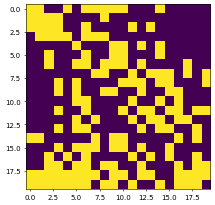

In [35]:
vec_env.envs[0].M.draw(obs)

In [36]:
vec_env.envs[0].args = get_args(*mbb_beam(rd=vec_env.envs[0].rd))
t__, c__ = fast_stopt(vec_env.envs[0].args, obs)
t__

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.rd to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.rd` for environment variables or `env.get_wrapper_attr('rd')` that will search the reminding wrappers.
  logger.warn(


105.46566826567825

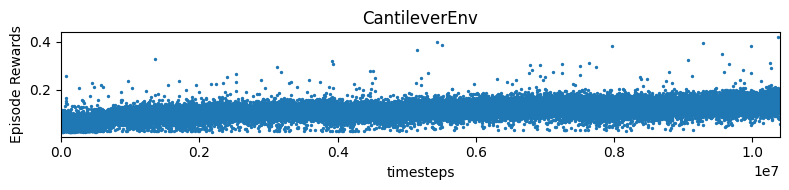

In [37]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [38]:
obs=vec_env.reset()

In [39]:
# Load the agent
model_best = PPO.load(log_dir + "best_model.zip",env=vec_env)

In [40]:
i=0
while i<1000:
    action, _states = model_best.predict(obs, deterministic=True)
    obs_prev=obs
    obs, rewards, dones, info = vec_env.step(action)
    if dones[0]:
        break
    i+=1

In [41]:
obs_=obs_prev[0].reshape(y0,x0)


Final Cantilever beam design:


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


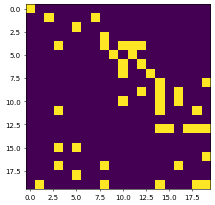

In [42]:
vec_env.envs[0].M.draw(obs_)

In [43]:
vec_env.envs[0].args = get_args(*mbb_beam(rd=vec_env.envs[0].rd))
t__, c__ = fast_stopt(vec_env.envs[0].args, obs_)
t__

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.rd to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.rd` for environment variables or `env.get_wrapper_attr('rd')` that will search the reminding wrappers.
  logger.warn(


147473.06390976484

In [44]:
def refine_and_draw_topology(matrix, blur_radius=0, threshold=0.5):
    
    blur_radius = int(blur_radius)
    size = 2 * blur_radius + 1
    grad_h, grad_w = int(matrix.shape[0]), int(matrix.shape[1])
    
    smoothed = np.copy(matrix)
    
    for y in range(grad_h):
        for x in range(grad_w):
            y_min, y_max = max(0, y - blur_radius), min(grad_h, y + blur_radius + 1)
            x_min, x_max = max(0, x - blur_radius), min(grad_w, x + blur_radius + 1)
            smoothed[y, x] = np.mean(matrix[y_min:y_max, x_min:x_max])
            
    final_geometry = (smoothed >= threshold).astype(float)
    return smoothed, final_geometry

In [45]:
smoothed, final_geometry= refine_and_draw_topology(obs_, blur_radius=1, threshold=0.11)


Final Cantilever beam design:


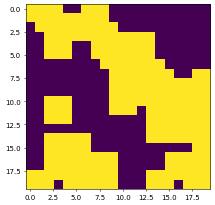

In [46]:
vec_env.envs[0].M.draw(final_geometry)

In [47]:
vec_env.envs[0].args = get_args(*mbb_beam(rd=vec_env.envs[0].rd))
t__, c__ = fast_stopt(vec_env.envs[0].args, final_geometry)
t__

376.09737651597095